In [ ]:
# Dataset Cleaning Basics

# This notebook shows basic techniques for:
# Handling missing values
# Handling outliers
# Encoding categorical data

In [11]:
# Import libraries
# Handling Missing Values

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Sample dataset with missing values

data_missing = {
    "Name": ["Ana", "Ben", "Chris", "Dana", "Eli"],
    "Age": [23, np.nan, 30, 25, np.nan],
    "Score": [85, 90, np.nan, 70, 95]
}

df_missing = pd.DataFrame(data_missing)
df_missing

,Name,Age,Score
0,Ana,23.0,85.0
1,Ben,NaN,90.0
2,Chris,30.0,NaN
3,Dana,25.0,70.0
4,Eli,NaN,95.0


In [4]:
# Check how many missing values per column

df_missing.isna().sum()

Name     0
Age      2
Score    1
dtype: int64

In [5]:
# Option 1: Drop rows with missing values
# Drop rows with any missing values

df_drop_rows = df_missing.dropna()
df_drop_rows


,Name,Age,Score
0,Ana,23.0,85.0
3,Dana,25.0,70.0


In [6]:
# Option 2: Fill missing values with mean/median
# Fill the missing Age with the mean

df_fill = df_missing.copy()
df_fill["Age"] = df_fill["Age"].fillna(df_fill["Age"].mean())

# Fill missing Score with median
df_fill["Score"] = df_fill["Score"].fillna(df_fill["Score"].median())

df_fill

,Name,Age,Score
0,Ana,23.0,85.0
1,Ben,26.0,90.0
2,Chris,30.0,87.5
3,Dana,25.0,70.0
4,Eli,26.0,95.0


In [7]:
# Handling Outliers
# Create sample dataset with outliers
# Sample dataset with outliers

data_outliers = {
    "Student": ["A", "B", "C", "D", "E", "F", "G"],
    "Score": [80, 82, 79, 400, 83, 81, 78]  # 400 is an outlier
}

df_outliers = pd.DataFrame(data_outliers)
df_outliers

,Student,Score
0,A,80
1,B,82
2,C,79
3,D,400
4,E,83
5,F,81
6,G,78


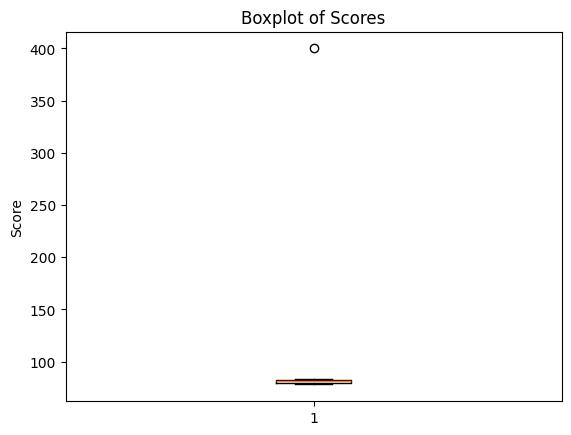

In [8]:
plt.boxplot(df_outliers["Score"])
plt.title("Boxplot of Scores")
plt.ylabel("Score")
plt.show()

In [9]:
# Detect outliers using IQR
# Calculate Q1, Q3, and IQR

Q1 = df_outliers["Score"].quantile(0.25)
Q3 = df_outliers["Score"].quantile(0.75)
IQR = Q3 - Q1

# Define lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

lower_bound, upper_bound


(np.float64(75.0), np.float64(87.0))

In [10]:
# Remove outliers
# Keep only values within the bounds

df_no_outliers = df_outliers[
    (df_outliers["Score"] >= lower_bound) &
    (df_outliers["Score"] <= upper_bound)
]

df_no_outliers

,Student,Score
0,A,80
1,B,82
2,C,79
4,E,83
5,F,81
6,G,78


In [12]:
# Encoding Categorical Data
# Create a sample dataset with categorical values

data_cat = {
    "Color": ["Red", "Blue", "Green", "Blue", "Red"],
    "Size": ["Small", "Medium", "Large", "Medium", "Small"],
    "Price": [10, 12, 15, 11, 9]
}

df_cat = pd.DataFrame(data_cat)
df_cat

,Color,Size,Price
0,Red,Small,10
1,Blue,Medium,12
2,Green,Large,15
3,Blue,Medium,11
4,Red,Small,9


In [13]:
# Label Encoding (simple categories → numbers)
# Manual label encoding for 'Color'

color_mapping = {"Red": 0, "Blue": 1, "Green": 2}
df_cat["Color_encoded"] = df_cat["Color"].map(color_mapping)

df_cat

,Color,Size,Price,Color_encoded
0,Red,Small,10,0
1,Blue,Medium,12,1
2,Green,Large,15,2
3,Blue,Medium,11,1
4,Red,Small,9,0


In [14]:
# One-Hot Encoding (get_dummies)
# One-hot encode the 'Size' column
df_one_hot = pd.get_dummies(df_cat, columns=["Size"])

df_one_hot

,Color,Price,Color_encoded,Size_Large,Size_Medium,Size_Small
0,Red,10,0,False,False,True
1,Blue,12,1,False,True,False
2,Green,15,2,True,False,False
3,Blue,11,1,False,True,False
4,Red,9,0,False,False,True


In [ ]:
# Label Encoding assigns a number to each category (e.g., Red=0, Blue=1, Green=2).
# One-Hot Encoding creates new columns (e.g., Size_Small, Size_Medium, Size_Large) with 0/1 values.
# These encodings convert text categories into numeric form so they can be used by machine learning models.